In [ ]:
% pip install numpy panda matplotlib seaborn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Titanic Survival Analysis: Understanding Factors That Influenced Survival

## Objective
The goal of this analysis is to understand which factors (such as age, gender, and passenger class) influenced survival on the Titanic.

## Dataset Overview
The Titanic dataset contains information about passengers including their age, sex, ticket class, fare, and whether they survived or not.

In [5]:
df = sns.load_dataset("titanic")
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


## Basic Information and Statistics

The Titanic dataset contains records for 891 passengers including both male and female passengers distributed across First, Second and Third class, with ages distributed between 0 and 80 years.

In [6]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Total Survival Count

Text(0.5, 1.0, 'Distribution of Survived and Non-Survived Passengers in Titanic ')

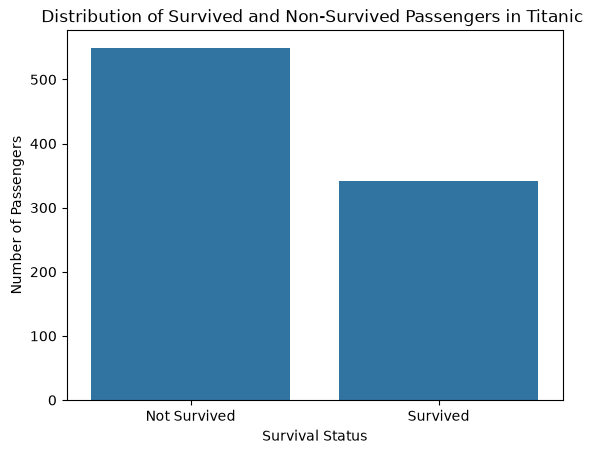

In [9]:
df["Survival"] = df["survived"].map({0: "Not Survived", 1: "Survived"})
sns.countplot(x = "Survival", data = df)
plt.xlabel("Survival Status")
plt.ylabel("Number of Passengers")
plt.title("Distribution of Survived and Non-Survived Passengers in Titanic ")

## 1. Survival count by gender:

Text(0.5, 0, 'Survival Status')

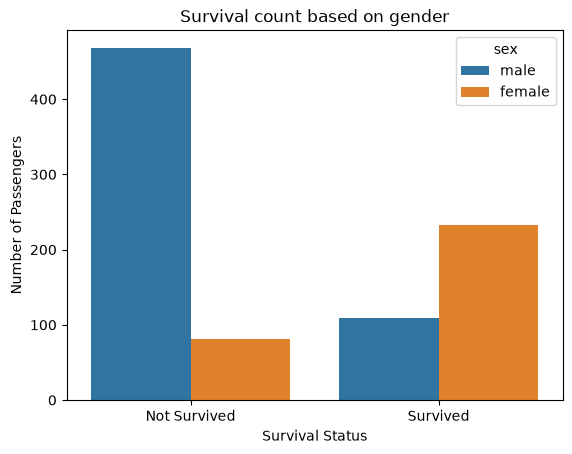

In [10]:
sns.countplot(x ="Survival", hue = "sex", data = df)
plt.title("Survival count based on gender")
plt.ylabel("Number of Passengers")
plt.xlabel("Survival Status")

## 2. Survival count by Passenger Class

Text(0.5, 0, 'Survival Status')

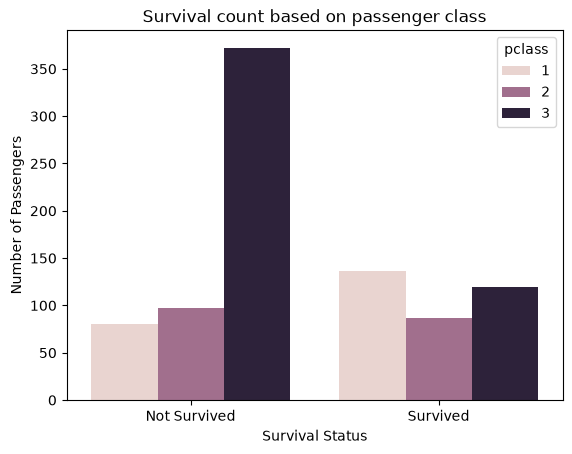

In [11]:
sns.countplot(x = "Survival", hue = "pclass", data=df)
plt.title("Survival count based on passenger class")
plt.ylabel("Number of Passengers")
plt.xlabel("Survival Status")

## 3. Survival count by age

Text(0.5, 0, 'Age of Passenger')

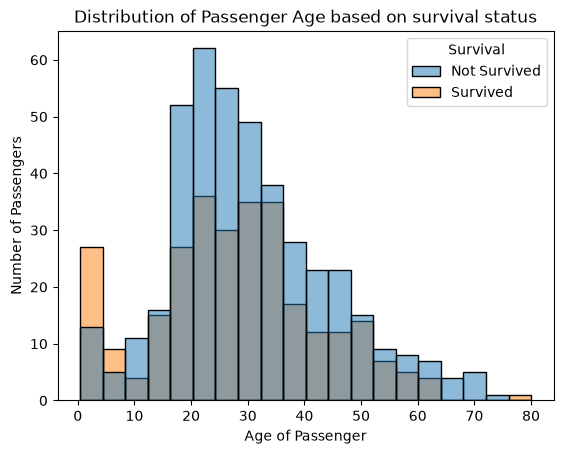

In [14]:
sns.histplot(
    data=df,
    x="age",
    hue="Survival",
    bins=20
)
plt.title("Distribution of Passenger Age based on survival status")
plt.ylabel("Number of Passengers")
plt.xlabel("Age of Passenger")

## Survival Rate Analysis

In [15]:
survival_rate = df["survived"].mean() * 100

print(
    f"Overall Survival Rate: {survival_rate}%"
)


Overall Survival Rate: 38.38383838383838%


### Insight
Approximately 38% of Titanic passengers survived, while around 62% did not survive indicating a relatively low overall survival rate.

## Survival Rate based on gender

Text(0, 0.5, 'Survival Rate (%)')

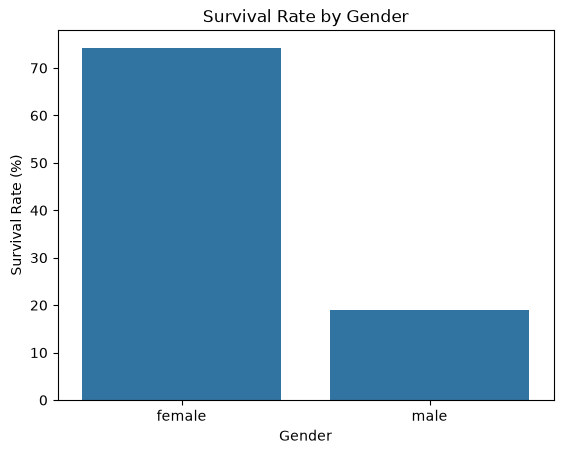

In [16]:
survival_gender = (
    df.groupby("sex")["survived"]
    .mean()
    * 100
)

sns.barplot(
    x=survival_gender.index,
    y=survival_gender.values
)

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate (%)")

### Insight
Female passengers had a substantially higher survival rate compared to male passengers.

## Survival Rate based on passenger class

Text(0, 0.5, 'Survival Rate (%)')

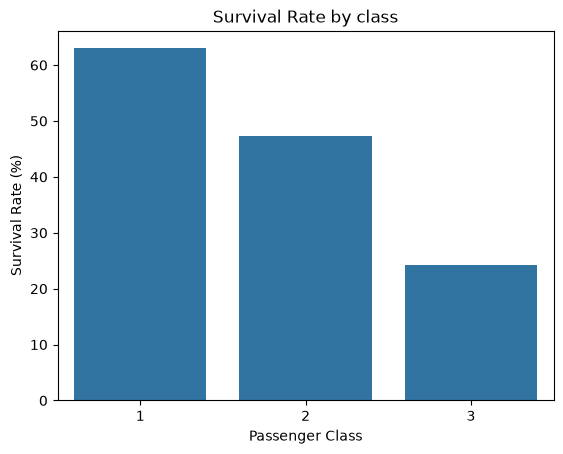

In [17]:
survival_by_class = (
    df.groupby("pclass")["survived"]
    .mean()
    * 100
)
sns.barplot(x=survival_by_class.index, y= survival_by_class.values)
plt.title("Survival Rate by class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")


### Insight
Passengers travelling in First Class had the highest survival rate, while Third Class passengers experienced the lowest survival rate.

## Survival Rate based on Age

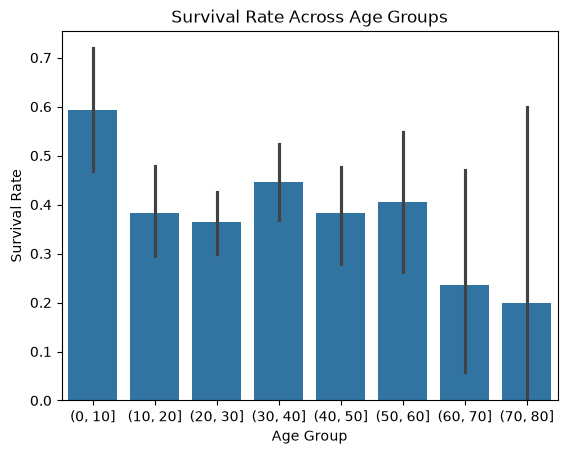

In [18]:
survived_df = df.copy()

survived_df["age_group"] = pd.cut(
    survived_df["age"],
    bins=[0,10,20,30,40,50,60,70,80]
)

sns.barplot(
    x="age_group",
    y="survived",
    data=survived_df
)

plt.title("Survival Rate Across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate")

plt.show()

### Insight
Survival rates appear to differ across age groups. Younger passengers show relatively stronger survival outcomes compared with several older age categories, although age alone does not fully explain survival.

## Relationship between age, sex and  passenger class

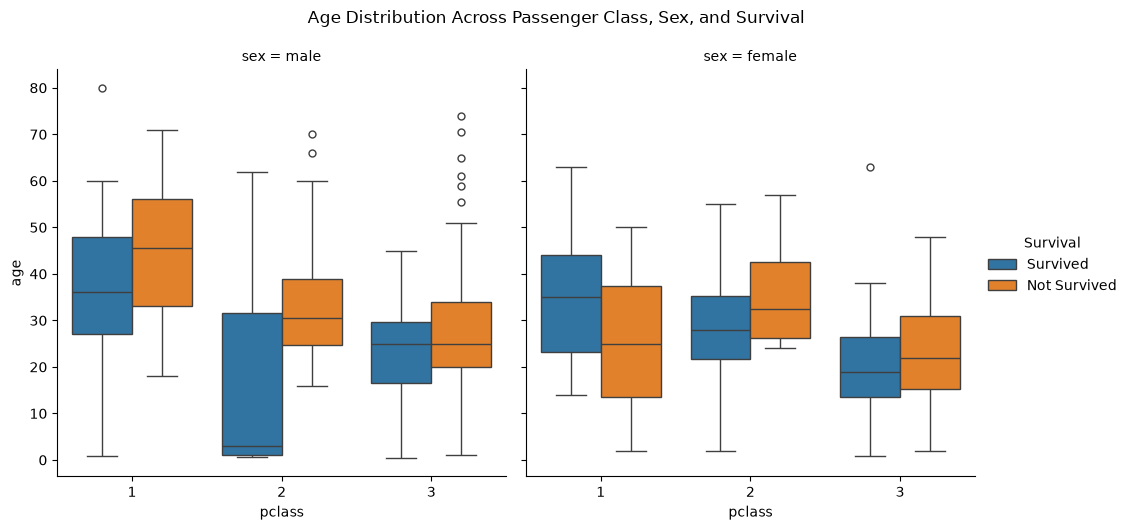

In [20]:
g = sns.catplot(
    data=df,
    x="pclass",
    y="age",
    hue="Survival",
    col="sex",
    kind="box"
)
g.fig.suptitle(
    "Age Distribution Across Passenger Class, Sex, and Survival",
    y=1.05
)
plt.show()

### Insight
The visualization suggests that survival was not determined by a single factor. Age distribution varies across passenger classes and between males and females, while survival outcomes appear more favorable among certain demographic groups.

## Key Takeaways

* Survival outcomes were influenced by multiple factors rather than a single characteristic.
* Passenger class showed a noticeable relationship with survival, with higher classes generally appearing to experience better outcomes.
* Survival patterns differed between male and female passengers across classes.
* Age alone did not fully explain survival differences, but age distributions varied across passenger groups.
* Combining demographic and travel-related variables provided stronger insights than analyzing variables individually.


## Conclusion

This analysis explored how passenger characteristics influenced survival outcomes in the Titanic dataset. Through exploratory data analysis and visualizations, survival appeared to vary across passenger class, sex, and age groups. The results suggest that survival was shaped by the interaction of multiple factors rather than one variable in isolation.

This project demonstrates how data visualization and exploratory analysis can be used to uncover patterns, generate insights, and support data-driven interpretation before applying predictive or machine learning techniques.
